In [ ]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [43]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x=pbc_x
        self.pbc_y=pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return np.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = np.subtract(rj, ri) # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr
    
    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"
        
    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if x < edge_width or x >= X - edge_width or y < edge_width or y >= Y - edge_width:
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                edgecolor="none",
                                                boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


In [44]:
def delta(x, eta=1e-6): # Lorentzian approximation of delta function
    return eta / (PI * (eta**2 + x**2))

def lorentzian(x, eta=1e-6):
    return eta / (PI * (x**2 + eta**2))

def fermi_dirac(energy, T=1e-6):
    if T == 0:
        return np.zeros_like(energy)
    else:
        return 1.0 / (np.exp((energy) / T) + 1.0)

def is_hermitian(matrix, atol=1e-8, rtol=1e-6):
    is_hermitian = np.allclose(matrix, matrix.conj().T, rtol=rtol, atol=atol)
    return is_hermitian


In [135]:
class Hamiltonian:
    def __init__(self, t, mu, lattice,
                 U=None, V=None, V_prime=None,
                 F0_init = 0, F_init = np.zeros(4),
                 Fuu_init = np.zeros(4), 
                 Fdd_init = np.zeros(4)):
        
        '''
        Builds k-independent Hamiltonian matrix 
        '''
        self.t = t 
        self.mu = mu
        self.lattice = lattice
        Nx = lattice.X
        self.dim = 4 * Nx

        if U is None:
            U = np.zeros(Nx)
        if V is None:
            V = np.zeros(Nx)
        if V_prime is None:
            V_prime = np.zeros(Nx)
        self.U = U
        self.V = V
        self.V_prime = V_prime

        self.F0 = np.ones(Nx, dtype=np.complex128) * F0_init
        
        self.F_xplus = np.ones(Nx-1, dtype=np.complex128) * F_init[0]
        self.F_xmin = np.ones(Nx-1, dtype=np.complex128) * F_init[1]
        self.F_yplus = np.ones(Nx, dtype=np.complex128) * F_init[2]
        self.F_ymin = np.ones(Nx, dtype=np.complex128) * F_init[3]

        self.Fuu_xplus = np.ones(Nx-1, dtype=np.complex128) * Fuu_init[0]
        self.Fuu_xmin = np.ones(Nx-1, dtype=np.complex128) * Fuu_init[1]
        self.Fuu_yplus = np.ones(Nx, dtype=np.complex128) * Fuu_init[2]
        self.Fuu_ymin = np.ones(Nx, dtype=np.complex128) * Fuu_init[3]

        self.Fdd_xplus = np.ones(Nx-1, dtype=np.complex128) * Fdd_init[0]
        self.Fdd_xmin = np.ones(Nx-1, dtype=np.complex128) * Fdd_init[1]
        self.Fdd_yplus = np.ones(Nx, dtype=np.complex128) * Fdd_init[2]
        self.Fdd_ymin = np.ones(Nx, dtype=np.complex128) * Fdd_init[3]
        
        gap0 = U * self.F0
        gap1 = V[1:] * self.F_xmin
        gap2 = V[:-1] * self.F_xplus
        gap1_uu = V_prime[1:] * self.Fuu_xmin
        gap2_uu = V_prime[:-1] * self.Fuu_xplus
        gap1_dd = V_prime[1:] * self.Fuu_xmin
        gap2_dd = V_prime[:-1] * self.Fuu_xplus
        
        self.matrix = np.zeros((self.dim, self.dim), dtype=np.complex128)
        
        self.set_kindep(gap0, gap1, gap2, gap1_uu, gap2_uu, gap1_dd, gap2_dd)

    def is_hermitian(self, atol=1e-8, rtol=1e-6):
        if self.matrix is None:
            raise RuntimeError("Hamiltonian matrix not built yet. "
                               "Call build() first.")
        is_hermitian = np.allclose(self.matrix, self.matrix.conj().T, rtol=rtol, atol=atol)
        return is_hermitian

    def set_kindep(self, gap0, gap1, gap2, gap1_uu, gap2_uu, gap1_dd, gap2_dd):
        t = self.t
        diag = - self.mu #- 2.0 * t *cos(0)
        # set in diagonal elements (mu + 2cos(0))
        for i in range(self.lattice.X):
            sl = slice(4 * i, 4 * i + 4)
            self.matrix[sl,sl] += np.diag(np.array(
                [diag, diag, -diag, -diag]
            ))

            # set in BCS gap
            block = np.zeros((4, 4), dtype=np.complex128)
            block[0, 3] = gap0[i]
            block[1, 2] = -gap0[i]
            block[2, 1] = -gap0[i].conj()
            block[3, 0] = gap0[i].conj()
            self.matrix[sl,sl] += block

        # set in hopping block in x direction
        for i in range(self.lattice.X-1):
            idx = i
            sli = slice(4 * i, 4 * i + 4)
            slj = slice(4 * (i + 1), 4 * (i + 1) + 4)
            self.matrix[sli,slj] += np.diag(np.array(
                [-t, -t, t, t]
            ))
            self.matrix[slj,sli] += np.diag(np.array(
                [-t, -t, t, t]
            ))

            # x+
            upper = np.zeros((4, 4), dtype=np.complex128)
          
            upper[0, 3] = gap1[idx]
            upper[1, 2] = -gap2[idx]
            upper[2, 1] = -gap1[idx].conj()
            upper[3, 0] = gap2[idx].conj()

            upper[0, 2] = gap2_uu[idx]
            upper[1, 3] = gap2_dd[idx]
            upper[2, 0] = gap1_uu[idx].conj()
            upper[3, 1] = gap1_dd[idx].conj()

            # x-
            lower = np.zeros((4, 4), dtype=np.complex128)
            lower[0, 3] = gap2[idx]
            lower[1, 2] = -gap1[idx]
            lower[2, 1] = -gap2[idx].conj()
            lower[3, 0] = gap1[idx].conj()

            lower[0, 2] = gap1_uu[idx]
            lower[1, 3] = gap1_dd[idx]
            lower[2, 0] = gap2_uu[idx].conj()
            lower[3, 1] = gap2_dd[idx].conj()

            self.matrix[sli, slj] += upper
            self.matrix[slj, sli] += lower


    def get_correlations(self):
        return (self.F0, self.F_xplus, self.F_xmin, self.F_yplus, self.F_ymin,
                self.Fuu_xplus, self.Fuu_xmin, self.Fuu_yplus, self.Fuu_ymin,
                self.Fdd_xplus, self.Fdd_xmin, self.Fdd_yplus, self.Fdd_ymin)

    def set_correlations(self, corr):
        
        Nx = self.lattice.X

        self.F0 = corr[0]
        
        self.F_xplus = corr[1]
        self.F_xmin = corr[2]
        self.F_yplus = corr[3]
        self.F_ymin = corr[4]

        self.Fuu_xplus = corr[5]
        self.Fuu_xmin = corr[6]
        self.Fuu_yplus = corr[7]
        self.Fuu_ymin = corr[8]
        
        self.Fdd_xplus = corr[9]
        self.Fdd_xmin = corr[10]
        self.Fdd_yplus = corr[11]
        self.Fdd_ymin = corr[12]

        gap0 = self.U * self.F0
        gap1 = self.V[1:] * self.F_xmin
        gap2 = self.V[:-1] * self.F_xplus
        gap1_uu = self.V_prime[1:] * self.Fuu_xmin
        gap2_uu = self.V_prime[:-1] * self.Fuu_xplus
        gap1_dd = self.V_prime[1:] * self.Fuu_xmin
        gap2_dd = self.V_prime[:-1] * self.Fuu_xplus
        
        self.matrix = np.zeros((self.dim, self.dim), dtype=np.complex128)
        
        self.set_kindep(gap0, gap1, gap2, gap1_uu, gap2_uu, gap1_dd, gap2_dd)

    def get_dim(self):
        return self.dim
    
    def build_Hk(self, k):
        Hk = np.zeros((self.get_dim(), self.get_dim()), dtype=np.complex128)
        
        eps = -2.0 * self.t * np.cos(k)
        gap_y1 = self.V * (self.F_yplus * np.exp(-1j*k) +
                           self.F_ymin * np.exp(1j*k)) 
        gap_y2 = self.V * (self.F_yplus * np.exp(1j*k) +
                            self.F_ymin * np.exp(-1j*k))

        gap_uu_y = self.V_prime * (self.Fuu_yplus * np.exp(-1j*k) +
                                   self.Fuu_ymin * np.exp(1j*k))
        gap_dd_y = self.V_prime * (self.Fdd_yplus * np.exp(-1j*k) +
                                   self.Fdd_ymin * np.exp(1j*k))

        for i in range(self.lattice.X):
            sl = slice(4 * i, 4 * (i+1) )

            block = np.zeros((4,4), dtype=np.complex128)
            
            block[0,0] += eps
            block[1,1] += eps
            block[2,2] += -eps
            block[3,3] += -eps

            block[0, 3] += gap_y1[i]
            block[1, 2] += -gap_y2[i]
            block[2, 1] += -gap_y2[i].conj()
            block[3, 0] += gap_y1[i].conj()

            block[0,2] += gap_uu_y[i]
            block[1,3] += gap_dd_y[i]
            block[2,0] += gap_uu_y[i].conj()
            block[3,1] += gap_dd_y[i].conj()

            Hk[sl,sl] += block
            
        return Hk
    
    def dos_term(self, Hk, energies, eta=1e-3):
        evals,evecs = la.eigh(self.matrix+Hk, subset_by_value=(0.0, np.inf))
        Nx = evecs.shape[0] // 4     # number of lattice sites
        
        u_up = evecs[0:4*Nx:4, :] # u0 = u_up
        u_dn = evecs[1:4*Nx:4, :] # v0 = u_dn
        v_up = evecs[2:4*Nx:4, :] # w0 = v_up
        v_dn = evecs[3:4*Nx:4, :] # x0 = v_dn

        w_pos = np.sum(np.abs(u_up)**2 + np.abs(u_dn)**2, axis=0)  # (M,)
        w_neg = np.sum(np.abs(v_up)**2 + np.abs(v_dn)**2, axis=0)

        Lp = lorentzian(energies[:, None] - evals[None, :], eta=eta)
        Ln = lorentzian(energies[:, None] + evals[None, :], eta=eta)

        dos_values = np.einsum('gm,m->g', Lp, w_pos) + np.einsum('gm,m->g', Ln, w_neg)
        return dos_values
    
    def dos(self, energies, eta, idx=None, drop_matrix=False):
        Ny = self.lattice.Y
        ky_list = np.linspace(PI/Ny, PI, Ny)

        energies = energies.ravel() 
        dos_values = np.zeros_like(energies)

        Hk = self.build_Hk(0)
        dos_values += self.dos_term(Hk, energies, eta)
        
        def work(ky):
            Hk = self.build_Hk(ky)
            return self.dos_term(Hk, energies, eta)

        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            parts = list(ex.map(work, ky_list))

        return np.sum(parts, axis=0)

    def free_energy(self, temperature): ### broken ????
        Ny = self.lattice.Y
        ky_list = np.linspace(PI/Ny, PI, Ny)
        
        def work(ky):
            Hk = self.build_Hk(ky)
            eps = np.linalg.eigvalsh(self.matrix + Hk)
            eps = eps[eps>0]
            internal_energy = -0.5 * np.sum(eps)

            if temperature == 0:
                S = 0
            elif temperature > 0:
                S = np.sum(np.log(1 + np.exp(-eps / temperature)))

            return internal_energy - temperature * S
        
        part0 = work(0)

        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            parts = list(ex.map(work, ky_list))
        
        E_S = 0
            
        E_S += np.sum(self.U * np.abs(self.F0)**2)

        E_S += np.sum(self.V[:len(self.F_xplus)] *
                          (np.abs(self.F_xplus)**2 + np.abs(self.F_xmin)**2))
        E_S += np.sum(np.abs(self.F_yplus)**2 + np.abs(self.F_ymin)**2)

        E_S += np.sum(self.V_prime[:len(self.Fdd_xplus)] * 
                      (np.abs(self.Fdd_xplus)**2 + np.abs(self.Fdd_xmin)**2))
        E_S += np.sum(self.V_prime * (np.abs(self.Fdd_yplus)**2 + np.abs(self.Fdd_ymin)**2))

        E_S += np.sum(self.V_prime[:len(self.Fuu_xplus)] * 
                      (np.abs(self.Fuu_xplus)**2 + np.abs(self.Fuu_xmin)**2))
        E_S += np.sum(self.V_prime * (np.abs(self.Fuu_yplus)**2 + np.abs(self.Fuu_ymin)**2))
            
        return np.sum(parts) - part0 + E_S

In [136]:
def corr_k(H, k, temperature):
    Ny = H.lattice.Y
    Hk = H.build_Hk(k)
    evals,evecs = la.eigh(H.matrix+Hk, subset_by_value=(0.0, np.inf))

    f = fermi_dirac(evals, temperature)          # (Neig,)

    Nx = evecs.shape[0] // 4     # number of lattice sites

    u_up = evecs[0:4*Nx:4, :] # u0 = u_up
    u_dn = evecs[1:4*Nx:4, :] # v0 = u_dn
    v_up = evecs[2:4*Nx:4, :] # w0 = v_up
    v_dn = evecs[3:4*Nx:4, :] # x0 = v_dn

    exp_m = np.exp(-1j * k)
    exp_p = np.exp(1j * k)

    F0 = (np.einsum('nm,nm,m->n', u_up, np.conj(v_dn), (1.0 - f)) +
          np.einsum('nm,nm,m->n', u_dn, np.conj(v_up), f)) / Ny

    F_xplus = (np.einsum('nm,nm,m->n', u_up[:-1, :], np.conj(v_dn[1:, :]), (1.0 - f)) +
               np.einsum('nm,nm,m->n', u_dn[1:, :], np.conj(v_up[:-1, :]), f))/Ny
    F_xmin = (np.einsum('nm,nm,m->n', u_up[1:, :], np.conj(v_dn[:-1, :]), (1.0 - f)) +
              np.einsum('nm,nm,m->n', u_dn[:-1, :], np.conj(v_up[1:, :]), f))/Ny
    
    Fy1 = np.einsum('nm,nm,m->n', u_up, np.conj(v_dn), (1.0 - f))
    Fy2 = np.einsum('nm,nm,m->n', u_dn, np.conj(v_up), f)
    F_yplus = (Fy1 * exp_p + Fy2 * exp_m) / Ny
    F_ymin  = (Fy1 * exp_m + Fy2 * exp_p) / Ny

    Fuu_xplus = (
            np.einsum('nm,nm,m->n', u_up[:-1, :], np.conj(v_up[1:, :]), (1 - f)) +
            np.einsum('nm,nm,m->n', u_up[1:, :], np.conj(v_up)[:-1, :], f)
    ) / Ny
    Fuu_xmin = (
        np.einsum('nm,nm,m->n', u_up[1:, :], np.conj(v_up[:-1, :]), (1 - f)) +
        np.einsum('nm,nm,m->n', u_up[:-1, :], np.conj(v_up)[1:, :], f)
    ) / Ny
    Fuu_yplus = (
        np.einsum('nm,nm,m->n', u_up, np.conj(v_up), (1.0 - f)) * exp_p + 
        np.einsum('nm,nm,m->n', u_up, np.conj(v_up), f) * exp_m
    ) / Ny
    Fuu_ymin = (
        np.einsum('nm,nm,m->n', u_up, np.conj(v_up), (1.0 - f)) * exp_m + 
        np.einsum('nm,nm,m->n', u_up, np.conj(v_up), f) * exp_p
    ) / Ny

    Fdd_xplus = (
        np.einsum('nm,nm,m->n', u_dn[:-1, :], np.conj(v_dn[1:, :]), (1 - f)) +
        np.einsum('nm,nm,m->n', u_dn[1:, :], np.conj(v_dn)[:-1, :], f)
    ) / Ny
    Fdd_xmin = (
        np.einsum('nm,nm,m->n', u_dn[1:, :], np.conj(v_dn[:-1, :]), (1 - f)) +
        np.einsum('nm,nm,m->n', u_dn[:-1, :], np.conj(v_dn)[1:, :], f)
    ) / Ny
    Fdd_yplus = (
        np.einsum('nm,nm,m->n', u_dn, np.conj(v_dn), (1.0 - f)) * exp_p + 
        np.einsum('nm,nm,m->n', u_dn, np.conj(v_dn), f) * exp_m
    ) / Ny
    Fdd_ymin = (
        np.einsum('nm,nm,m->n', u_dn, np.conj(v_dn), (1.0 - f)) * exp_m + 
        np.einsum('nm,nm,m->n', u_dn, np.conj(v_dn), f) * exp_p
    ) / Ny
    acc = (F0, F_xplus, F_xmin, F_yplus, F_ymin,
            Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,
            Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin)

    # comps = (FS_x, FS_y, FT_xplus, FT_xmin, FT_yplus,FT_ymin)
    return acc

In [137]:
def bdg_self_consistency_step(H, temperature = 0):
    Ny = H.lattice.Y
    ky_list = np.linspace(PI/Ny, PI, Ny)
    acc = corr_k(H, 0, temperature=temperature)

    for ky in ky_list:
        corr = corr_k(H, ky, temperature=temperature)
        acc = tuple(a + b for a, b in zip(acc, corr))
    
    return acc

In [138]:
def bdg_self_consistency(H:Hamiltonian, temperature=0,  # Hamiltonian
                         atol=1e-6, rtol=1e-4, maxiter=100, verbose=False):
    converged=False
    for iteration in range(maxiter):
        corr = H.get_correlations()
        corr_new = bdg_self_consistency_step(H, temperature)

        abs_diff = np.array([np.linalg.norm(c2-c1)
                             for c1,c2 in zip(corr,corr_new)])
        
        rel_diff = np.array([np.linalg.norm((c2-c1)/(c1 + 1e-12))
                             for c1,c2 in zip(corr, corr_new)])

        if verbose:
            print('============================================')
            print(f"Iteration {iteration + 1}:")
            correlation_strings = [
                "F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin",
                "Fuu_xplus", "Fuu_xmin", "Fuu_yplus", "Fuu_ymin",
                "Fdd_xplus", "Fdd_xmin", "Fdd_yplus", "Fdd_ymin"
            ]
            for idx in range(len(abs_diff)):
                print(f"{correlation_strings[idx]}:")
                print(f"Absolute error: {abs_diff[idx]}")
                print(f"Relative error: {rel_diff[idx]}")
                print(f"Average_old: {np.mean(corr[idx])}")
                print(f"Average_new: {np.mean(corr_new[idx])}")

        if np.all(abs_diff < atol) and np.all(rel_diff < rtol):
            print(f"Converged after {iteration + 1} iterations")
            converged = True
            H.set_correlations(corr_new)
            break
        H.matrix
        H.set_correlations(corr_new)
    
    if not converged:
        print(f"WARNING: Failed to converge after {maxiter} iterations")

In [167]:
t = 1
mu = -1.6 * t
X, Y = 30, 30

lattice = Lattice(X, Y)

U0 = 2.0 * t * 0
U = U0 * np.ones(lattice.X)
V0 = 2 * t 
V = V0 * np.ones(lattice.X)
V_prime = V * 0
H = Hamiltonian(t, mu, lattice, U=None, V_prime=None, V=V, F_init=[0.1, -0.1, 0.1j, -0.1j])

In [168]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
0j


In [169]:
bdg_self_consistency(H, maxiter=200, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 0.5543206854126355
Relative error: 554320685412.6355
Average_old: 0j
Average_new: (0.10077851682503089+0j)
F_xplus:
Absolute error: 0.8017895978354628
Relative error: 8.017895978274447
Average_old: (0.09999999999999999+0j)
Average_new: (-0.04870836190702542+0j)
F_xmin:
Absolute error: 1.1166954643760534
Relative error: 11.166954643872202
Average_old: (-0.09999999999999999+0j)
Average_new: (0.10730211698126495+0j)
F_yplus:
Absolute error: 0.15025504954731184
Relative error: 1.5025504954731184
Average_old: 0.1j
Average_new: (0.01665976815849253+0.08062932059332971j)
F_ymin:
Absolute error: 0.15025504954731184
Relative error: 1.5025504954731184
Average_old: -0.1j
Average_new: (0.01665976815849253-0.08062932059332971j)
Fuu_xplus:
Absolute error: 5.978958846884839e-17
Relative error: 5.9789588468848384e-05
Average_old: 0j
Average_new: (1.3601925982921898e-18+0j)
Fuu_xmin:
Absolute error: 8.900957397049188e-17
Relative error: 8.900957397049188e-05
Average_old

In [170]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 7.239136592402735e-10
Relative error: 6.059288749422037e-09
Average_old: (0.12127593013211191+0j)
Average_new: (0.1212759302433569+0j)
F_xplus:
Absolute error: 8.103142866732945e-05
Relative error: 0.0015399177730487565
Average_old: (0.052918732053971795+0j)
Average_new: (0.05290465734526397+0j)
F_xmin:
Absolute error: 8.103106548906277e-05
Relative error: 0.001540445984603594
Average_old: (0.05290380582985561+0j)
Average_new: (0.05291788048044746+0j)
F_yplus:
Absolute error: 9.13350010137296e-10
Relative error: 9.299701884864717e-09
Average_old: (0.042277102417536225+0.09078273790427147j)
Average_new: (0.04227710254305532+0.09078273796612078j)
F_ymin:
Absolute error: 9.13350010137296e-10
Relative error: 9.299701884864717e-09
Average_old: (0.042277102417536225-0.09078273790427147j)
Average_new: (0.04227710254305532-0.09078273796612078j)
Fuu_xplus:
Absolute error: 5.915798523860687e-17
Relative error: 5.9158803545155306e-05
Average_old: (-2.0948249862278

In [171]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))
# gap_0 = 0.1 + 0.2j
# block = np.zeros((4,4), dtype=np.complex128)
# block[:2, :2] = -mu * s0
# block[2:, 2:] = mu * s0
# block[:2, 2:] = -1j * gap_0 * s2
# block[2:, :2] = (-1j * gap_0 * s2).conj().T
# print(block)


True
True
(0.1212759302433569+0j)


In [172]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [176]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = F_xmin       # site i gets bond (i,i-1).T

print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)

(-6.391182005350757e-06+0j)
0.09078273796612078j
(0.004435228703019263+0j)
(0.046712331246074594+0j)


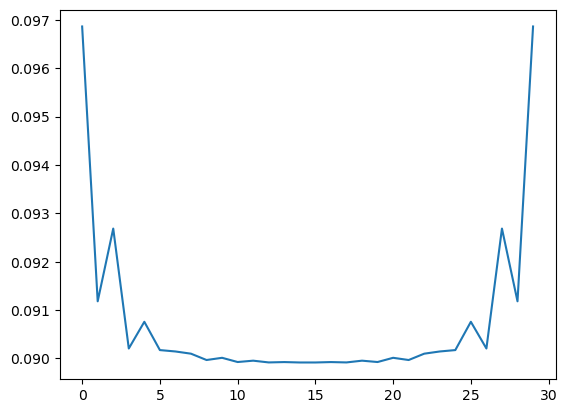

In [174]:
# plt.plot(np.real(Fx_p + Fx_m)/2)
plt.plot(np.imag(F_yplus - F_ymin)/2)

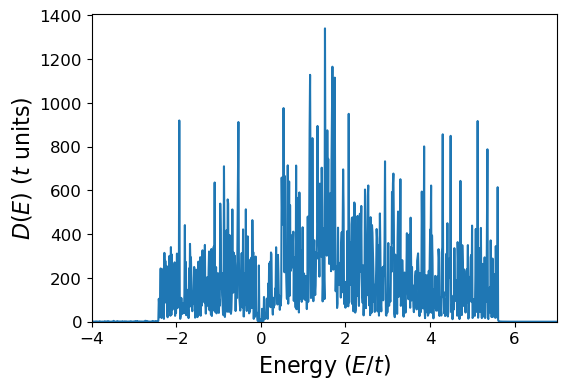

In [175]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.001)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [106]:
print(H.free_energy(0))

-21697.099609235174


In [107]:
# %prun H.dos(energies, eta=1e-3)